# Crude predictors: what forecasts the next inventory build or draw?

This standalone research notebook reviews `us_snd_model.py`, its README, and the cached EIA panels in both model directories. **One aspect of SnD is held fixed: national monthly inventory change**, rather than stock level. Crude stocks are commercial inventories excluding SPR; gasoline includes finished gasoline plus blending components. Predicting level can appear successful simply because last month's inventory persists; predicting the change asks which signals anticipate a build/draw.

The existing crude model selects seasonal-change forecasts for all five PADDs; gasoline selects a mixture of seasonal residual regression, neural network, and random forests (see `model_output/selected_models.csv`). This motivates explicit tests of whether physical variables improve on the seasonal calendar.

**Timing and scope.** Target month t uses monthly predictors no later than t−1; calendar is known ahead. These are revised-history, conditional one-step experiments, **not reconstructed real-time forecasts**: t−1 monthly EIA data may not be released before t begins. A three-month feature-lag stress test is included. No same-month balance components enter predictors. Crude published flows have a broader scope than commercial stocks (including reserve-related differences), so the flow identity is not imposed. Gasoline product supplied is the model's demand measure.

**Selection.** Six chronological expanding development blocks precede July 2024. Ridge penalties and two conservative forest settings are compared, followed by at most three greedy group additions. Rankings reuse these development blocks and are exploratory, not nested unbiased estimates. The July 2024–June 2026 period is held out from this notebook's selection, but was previously reviewed in the original project. Models are refitted monthly during that evaluation using only earlier eligible targets. March 2020–March 2021 targets and training rows whose lookback touches that interval are excluded; the calendar is never compressed before creating lags.

Run all cells from this directory or the repository root. Inputs are read-only local snapshots; no download, API key, model-output overwrite, or auxiliary artifact is required. All analysis, tables, and figures are embedded here. Dependencies: pandas, numpy, scikit-learn, matplotlib, nbformat/nbclient and the existing data-loader dependencies.


## Readout
**Seasonality is the strongest group. Recent inventory changes are the best additional predictors.** Removing seasonality from full ridge raises development MAE by 0.896 million barrels; removing inventory history raises it by 0.322 million. The best individual addition is last month's inventory change (0.403 million barrels lower development MAE than calendar alone), followed by the three-month average change.

The development-selected combination uses calendar, inventory history, and refinery utilization/capacity. July 2024–June 2026 MAE is **6.714 million barrels**, versus **6.900 million** for calendar ridge: **2.7% lower**, with an uncertainty interval that includes no improvement. The selected model's RMSE is slightly worse, so the MAE gain does not mean better control of large misses. January–June 2026 MAE rises to 14.357 million barrels, showing substantial instability. Using three-month-old predictors gives MAE of 6.757 million barrels.

For this relationship, prioritize the seasonal calendar and recent build/draw history; treat refinery activity as a secondary candidate. Standalone supply, trade, and cross-fuel additions do not establish reliable incremental skill. The physical hypothesis is that recent stock changes summarize the realized imbalance, while refinery activity describes crude demand; these tests establish predictive associations, not that mechanism or causality.


In [1]:
FUEL = 'crude'
from pathlib import Path
import sys, hashlib, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import sklearn
pd.set_option('display.max_rows', 60)
pd.set_option('display.max_colwidth', 100)
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'oil/us_snd_crude/crude_data.py').exists())
for fuel in ['crude', 'gasoline']:
    sys.path.insert(0, str(ROOT/f'oil/us_snd_{fuel}'))
from crude_data import load_panel as load_crude, FLOWS as CRUDE_FLOWS
from gasoline_data import load_panel as load_gasoline, FLOWS as GAS_FLOWS
panels = {'crude': load_crude(), 'gasoline': load_gasoline()}
national = {}
for fuel, panel in panels.items():
    assert panel.groupby('month').padd.nunique().eq(5).all()
    cols = (CRUDE_FLOWS + ['stock_kb', 'cdu_capacity_kbd']) if fuel == 'crude' else GAS_FLOWS + ['stock_kb']
    z = panel.groupby('month')[cols].sum(min_count=5).asfreq('MS')
    assert z.notna().all().all()
    # Every flow becomes thousand barrels/day; stocks become million barrels.
    if fuel == 'gasoline':
        for c in GAS_FLOWS:
            z[c.replace('_kb', '_kbd')] = z[c] / z.index.days_in_month
    z['stock_mb'] = z.stock_kb / 1000
    z['change_mb'] = z.stock_mb.diff()
    z['net_imports_kbd'] = z.imports_kbd - z.exports_kbd
    z['core_balance_kbd'] = z.production_kbd + z.net_imports_kbd - z.demand_kbd
    if fuel == 'crude':
        z['utilization'] = z.demand_kbd / z.cdu_capacity_kbd
    national[fuel] = z
manifest = []
for fuel in national:
    path = ROOT/f'oil/us_snd_{fuel}/data/eia_observations.csv'
    manifest.append({'fuel': fuel, 'start': national[fuel].index.min(), 'end': national[fuel].index.max(),
                     'months': len(national[fuel]), 'sha256': hashlib.sha256(path.read_bytes()).hexdigest()})
display(pd.DataFrame(manifest))
print('Python', platform.python_version(), '| pandas', pd.__version__, '| sklearn', sklearn.__version__)


,fuel,start,end,months,sha256
0,crude,2007-01-01,2026-06-01,234,d9eb20fae286737e399acc8151246437105aa71df066ed1338164a0c0c5026b1
1,gasoline,2007-01-01,2026-06-01,234,47b39e884223a433dc4fae806b2723b98df8837c91b356748894f98db28dbc5c


Python 3.13.9 | pandas 2.3.3 | sklearn 1.7.2


## Target and candidate information
Flow averages are normalized to thousand barrels/day before lagging, avoiding artificial month-length signals. Inventory features are in million barrels. All five PADDs are required for national totals.

In [2]:
def outside_covid(dates):
    return ~((dates >= pd.Timestamp('2020-03-01')) & (dates <= pd.Timestamp('2021-03-01')))

def make_design(lag=1):
    z = national[FUEL]
    other = national['gasoline' if FUEL == 'crude' else 'crude'].reindex(z.index)
    X = pd.DataFrame(index=z.index)
    groups = {}
    # Full month indicators allow asymmetric seasonal builds/draws.
    for month in range(1, 13):
        X[f'month_{month:02}'] = (X.index.month == month).astype(float)
    groups['seasonality'] = list(X.columns)
    def add(group, name, series):
        X[name] = series
        groups.setdefault(group, []).append(name)
    for c in ['stock_mb', 'change_mb']:
        add('inventory_history', f'{c}_lag{lag}', z[c].shift(lag))
    add('inventory_history', 'stock_vs_year_ago', z.stock_mb.shift(lag)-z.stock_mb.shift(lag+12))
    add('inventory_history', 'change_mean3', z.change_mb.shift(lag).rolling(3).mean())
    for group, cols in {'supply': ['production_kbd'], 'demand': ['demand_kbd'],
                        'trade': ['imports_kbd', 'exports_kbd'],
                        'balance': ['core_balance_kbd'],
                        'other_flows': ['adjustments_kbd', 'net_receipts_kbd'] + (['transfers_kbd', 'direct_use_kbd'] if FUEL == 'crude' else ['biofuels_kbd'])}.items():
        for c in cols:
            add(group, f'{c}_lag{lag}', z[c].shift(lag))
            add(group, f'{c}_mean3', z[c].shift(lag).rolling(3).mean())
    if FUEL == 'crude':
        add('refinery_capacity', 'utilization_lag', z.utilization.shift(lag))
        add('refinery_capacity', 'capacity_lag', z.cdu_capacity_kbd.shift(lag))
    for c in ['demand_kbd', 'production_kbd', 'change_mb']:
        add('cross_fuel', f'other_{c}_lag', other[c].shift(lag))
    y = z.change_mb.rename('actual')
    keep = X.notna().all(axis=1) & y.notna()
    X, y = X.loc[keep], y.loc[keep]
    # Conservative exclusion of every month in the maximum lookback window.
    eligible = outside_covid(X.index)
    for offset in range(lag, lag+13):
        eligible &= outside_covid(X.index-pd.DateOffset(months=offset))
    return X, y, groups, pd.Series(eligible, index=X.index)

X, y, groups, eligible = make_design()
HOLDOUT = pd.Timestamp('2024-07-01')
dev_dates = X.index[(X.index < HOLDOUT) & outside_covid(X.index)]
# Six expanding-window validation blocks, 12 scored months each.
folds = [pd.DatetimeIndex(a) for a in np.array_split(dev_dates[-72:], 6)]
display(pd.DataFrame([{'group': g, 'features': ', '.join(cols)} for g, cols in groups.items()]))
display(pd.DataFrame([{'fold': i+1, 'train_rows': int(((X.index < d.min()) & eligible).sum()),
                       'validation_start': d.min(), 'validation_end': d.max(), 'scored_months': len(d)} for i,d in enumerate(folds)]))
assert max(d.max() for d in folds) < HOLDOUT
assert X.index.is_monotonic_increasing and not X.index.has_duplicates
print('Target: next-month inventory change in million barrels; positive = build.')


,group,features
0,seasonality,"month_01, month_02, month_03, month_04, month_05, month_06, month_07, month_08, month_09, month_..."
1,inventory_history,"stock_mb_lag1, change_mb_lag1, stock_vs_year_ago, change_mean3"
2,supply,"production_kbd_lag1, production_kbd_mean3"
3,demand,"demand_kbd_lag1, demand_kbd_mean3"
4,trade,"imports_kbd_lag1, imports_kbd_mean3, exports_kbd_lag1, exports_kbd_mean3"
5,balance,"core_balance_kbd_lag1, core_balance_kbd_mean3"
6,other_flows,"adjustments_kbd_lag1, adjustments_kbd_mean3, net_receipts_kbd_lag1, net_receipts_kbd_mean3, tran..."
7,refinery_capacity,"utilization_lag, capacity_lag"
8,cross_fuel,"other_demand_kbd_lag, other_production_kbd_lag, other_change_mb_lag"


,fold,train_rows,validation_start,validation_end,scored_months
0,1,112,2017-06-01,2018-05-01,12
1,2,124,2018-06-01,2019-05-01,12
2,3,136,2019-06-01,2021-06-01,12
3,4,145,2021-07-01,2022-06-01,12
4,5,147,2022-07-01,2023-06-01,12
5,6,159,2023-07-01,2024-06-01,12


Target: next-month inventory change in million barrels; positive = build.


## Development comparison
Calendar-only ridge, historical calendar-month mean change, and zero change provide benchmarks. Ridge scaling is learned inside each training window. Block forecasts use newly observed lagged inputs, not recursive simulated paths; parameters remain fixed within each development block.

In [3]:
def estimator(kind, alpha):
    if kind == 'ridge':
        return make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    return RandomForestRegressor(n_estimators=160, min_samples_leaf=alpha, max_features=0.8, random_state=42, n_jobs=2)

def columns(group_names):
    return [c for g in group_names for c in groups[g]]

def evaluate(group_names, kind='ridge', alpha=10, blocks=None, design=None):
    xx, yy, ee = (X, y, eligible) if design is None else design
    rows = []
    for fold, dates in enumerate(folds if blocks is None else blocks):
        train = (xx.index < dates.min()) & ee
        assert xx.index[train].max() < dates.min()
        if kind in ['zero', 'seasonal_mean']:
            pred = np.zeros(len(dates)) if kind == 'zero' else pd.Series(yy[train]).groupby(yy[train].index.month).mean().reindex(dates.month).to_numpy()
        else:
            model = estimator(kind, alpha)
            model.fit(xx.loc[train, columns(group_names)], yy[train])
            pred = model.predict(xx.loc[dates, columns(group_names)])
        rows.append(pd.DataFrame({'month': dates, 'fold': fold+1, 'actual': yy.loc[dates].values, 'predicted': pred}))
    return pd.concat(rows, ignore_index=True)

def metrics(pred):
    return {'mae_mb': mean_absolute_error(pred.actual, pred.predicted),
            'rmse_mb': np.sqrt(mean_squared_error(pred.actual, pred.predicted)),
            'direction_accuracy': np.mean(np.sign(pred.actual) == np.sign(pred.predicted))}

records, specs, cv_predictions = [], {}, {}
def candidate(name, gs, kind='ridge', alpha=10):
    p = evaluate(gs, kind, alpha)
    specs[name] = (gs, kind, alpha)
    cv_predictions[name] = p
    records.append({'candidate': name, **metrics(p)})

candidate('zero_change', [], 'zero')
candidate('historical_month_mean', [], 'seasonal_mean')
for alpha in [1, 10, 100]:
    candidate(f'calendar_ridge_{alpha}', ['seasonality'], alpha=alpha)
    candidate(f'all_ridge_{alpha}', list(groups), alpha=alpha)
    for group in list(groups)[1:]:
        candidate(f'calendar_plus_{group}_{alpha}', ['seasonality', group], alpha=alpha)
for leaf in [5, 15]:
    candidate(f'all_forest_leaf{leaf}', list(groups), 'forest', leaf)
leaderboard = pd.DataFrame(records).sort_values('mae_mb').reset_index(drop=True)
# Greedy additions use development data only, capped at three noncalendar groups.
chosen = ['seasonality']
for step in range(3):
    options = []
    for group in groups:
        if group in chosen: continue
        for alpha in [1, 10, 100]:
            name = f'forward{step+1}_{group}_{alpha}'
            candidate(name, chosen+[group], alpha=alpha)
            options.append(records[-1])
    best = min(options, key=lambda r:r['mae_mb'])
    chosen = specs[best['candidate']][0]
leaderboard = pd.DataFrame(records).sort_values('mae_mb').reset_index(drop=True)
winner = leaderboard.iloc[0].candidate
print('Frozen development winner:', winner, specs[winner])
display(leaderboard.head(15))
# Rank group additions against the best calendar-only specification.
calendar_name = min([k for k in specs if k.startswith('calendar_ridge')], key=lambda k: metrics(cv_predictions[k])['mae_mb'])
calendar_mae = metrics(cv_predictions[calendar_name])['mae_mb']
addition = []
for group in list(groups)[1:]:
    names = [f'calendar_plus_{group}_{a}' for a in [1,10,100]]
    best = min(names, key=lambda k: metrics(cv_predictions[k])['mae_mb'])
    p = cv_predictions[best]
    diffs = p.assign(gain=np.abs(cv_predictions[calendar_name].actual-cv_predictions[calendar_name].predicted)-np.abs(p.actual-p.predicted)).groupby('fold').gain.mean()
    addition.append({'group': group, 'best_alpha': specs[best][2], 'cv_mae_mb': metrics(p)['mae_mb'],
                     'gain_vs_calendar_mb': calendar_mae-metrics(p)['mae_mb'], 'folds_improved_of_6': int((diffs>0).sum())})
addition = pd.DataFrame(addition).sort_values('gain_vs_calendar_mb', ascending=False)
display(addition)


Frozen development winner: forward2_refinery_capacity_10 (['seasonality', 'inventory_history', 'refinery_capacity'], 'ridge', 10)


,candidate,mae_mb,rmse_mb,direction_accuracy
0,forward2_refinery_capacity_10,8.812254,10.788449,0.763889
1,forward3_demand_10,8.812602,10.759997,0.777778
2,calendar_plus_inventory_history_10,8.839848,10.964557,0.722222
3,forward1_inventory_history_10,8.839848,10.964557,0.722222
4,forward2_demand_10,8.849235,10.787285,0.750000
5,forward3_demand_1,8.901895,10.848439,0.763889
6,forward1_inventory_history_100,8.908925,10.967662,0.722222
7,calendar_plus_inventory_history_100,8.908925,10.967662,0.722222
8,forward2_refinery_capacity_1,8.914079,10.867538,0.777778
9,forward2_demand_1,8.923224,10.877925,0.750000


,group,best_alpha,cv_mae_mb,gain_vs_calendar_mb,folds_improved_of_6
0,inventory_history,10,8.839848,0.419256,4
5,other_flows,1,9.208729,0.050375,3
6,refinery_capacity,10,9.284192,-0.025088,3
4,balance,100,9.318012,-0.058908,3
2,demand,100,9.371497,-0.112393,3
7,cross_fuel,100,9.511573,-0.252468,3
1,supply,100,9.533737,-0.274632,3
3,trade,100,10.011022,-0.751918,2


## Which predictors contribute?
Positive gains indicate useful predictive information. Ablations retrain the model and avoid misleading in-sample tree impurity rankings. Individual additions use a fixed calendar-selected penalty; group additions tune their penalties on development only.

,removed_group,mae_increase_mb
0,seasonality,0.896480
1,inventory_history,0.321764
3,demand,0.047238
7,refinery_capacity,0.006299
2,supply,-0.008790
5,balance,-0.046053
8,cross_fuel,-0.218465
6,other_flows,-0.286767
4,trade,-0.380713


,feature,group,gain_vs_calendar_mb
1,change_mb_lag1,inventory_history,0.403460
3,change_mean3,inventory_history,0.109931
12,core_balance_kbd_lag1,balance,0.079728
14,adjustments_kbd_lag1,other_flows,0.048559
0,stock_mb_lag1,inventory_history,0.042223
15,adjustments_kbd_mean3,other_flows,0.021744
20,direct_use_kbd_lag1,other_flows,0.000000
21,direct_use_kbd_mean3,other_flows,0.000000
2,stock_vs_year_ago,inventory_history,-0.000209
17,net_receipts_kbd_mean3,other_flows,-0.011705


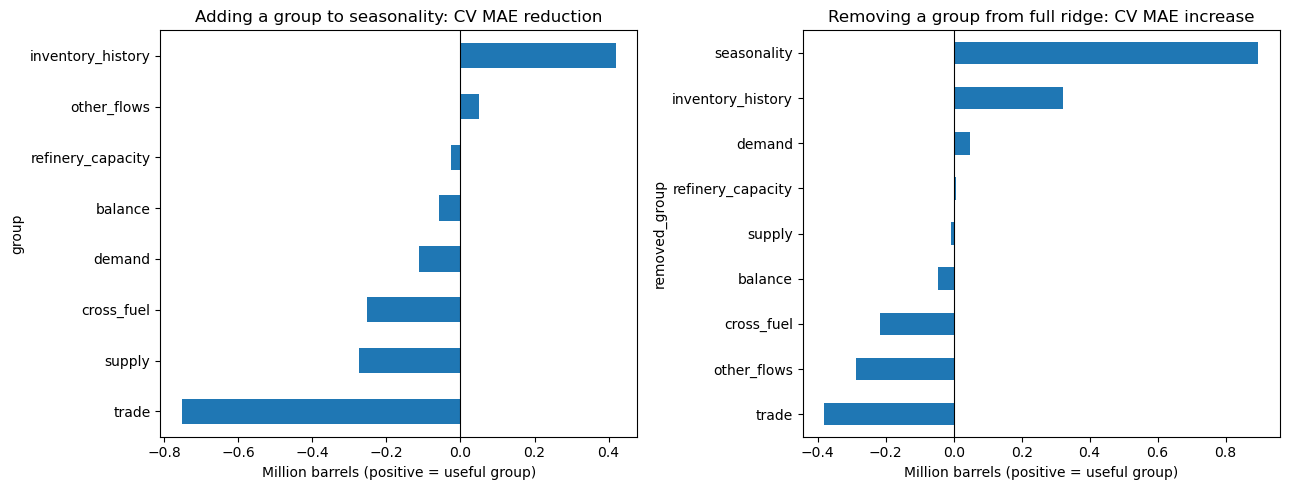

In [4]:
# Retrained group ablations: loss of skill after removing a group from full ridge.
full_name = min([f'all_ridge_{a}' for a in [1,10,100]], key=lambda k: metrics(cv_predictions[k])['mae_mb'])
full_alpha = specs[full_name][2]
full_mae = metrics(cv_predictions[full_name])['mae_mb']
ablation = []
for group in groups:
    p = evaluate([g for g in groups if g != group], alpha=full_alpha)
    ablation.append({'removed_group':group, 'mae_increase_mb':metrics(p)['mae_mb']-full_mae})
ablation = pd.DataFrame(ablation).sort_values('mae_increase_mb', ascending=False)
display(ablation)
# Individual additions, fixed calendar alpha: complements correlated group rankings.
individual = []
for group in list(groups)[1:]:
    for feature in groups[group]:
        groups['_single'] = [feature]
        p = evaluate(['seasonality', '_single'], alpha=specs[calendar_name][2])
        individual.append({'feature':feature, 'group':group, 'gain_vs_calendar_mb':calendar_mae-metrics(p)['mae_mb']})
del groups['_single']
individual = pd.DataFrame(individual).sort_values('gain_vs_calendar_mb', ascending=False)
display(individual.head(15))
fig, ax = plt.subplots(1,2,figsize=(13,5))
addition.set_index('group').gain_vs_calendar_mb.sort_values().plot.barh(ax=ax[0], title='Adding a group to seasonality: CV MAE reduction')
ablation.set_index('removed_group').mae_increase_mb.sort_values().plot.barh(ax=ax[1], title='Removing a group from full ridge: CV MAE increase')
for a in ax: a.axvline(0,color='black',lw=0.8); a.set_xlabel('Million barrels (positive = useful group)')
plt.tight_layout(); plt.show()


## Frozen selection: rolling final-period evaluation
Earlier final-period outcomes become training data for later predictions, as in sequential deployment. No final-period score changes the chosen specification. The bootstrap describes paired error uncertainty only; it does not account for model search or source-data revisions.

,candidate,mae_mb,rmse_mb,direction_accuracy
0,forward2_refinery_capacity_10,6.713690,9.408773,0.750000
1,calendar_ridge_10,6.900048,9.245459,0.708333
2,historical_month_mean,6.874819,9.246126,0.708333
3,zero_change,9.630542,12.194981,0.000000
4,all_ridge_100,7.074286,9.061235,0.791667


Holdout MAE gain over calendar: 0.186 million barrels; descriptive 95% block-bootstrap interval [-0.461, 0.886]


,months,mae_mb
year,,
2024,6,1.809525
2025,12,5.344286
2026,6,14.356664


,availability,mae_mb,rmse_mb,direction_accuracy
0,previous month (research assumption),6.713690,9.408773,0.750000
1,three-month lag (stress test),6.756858,9.222144,0.791667


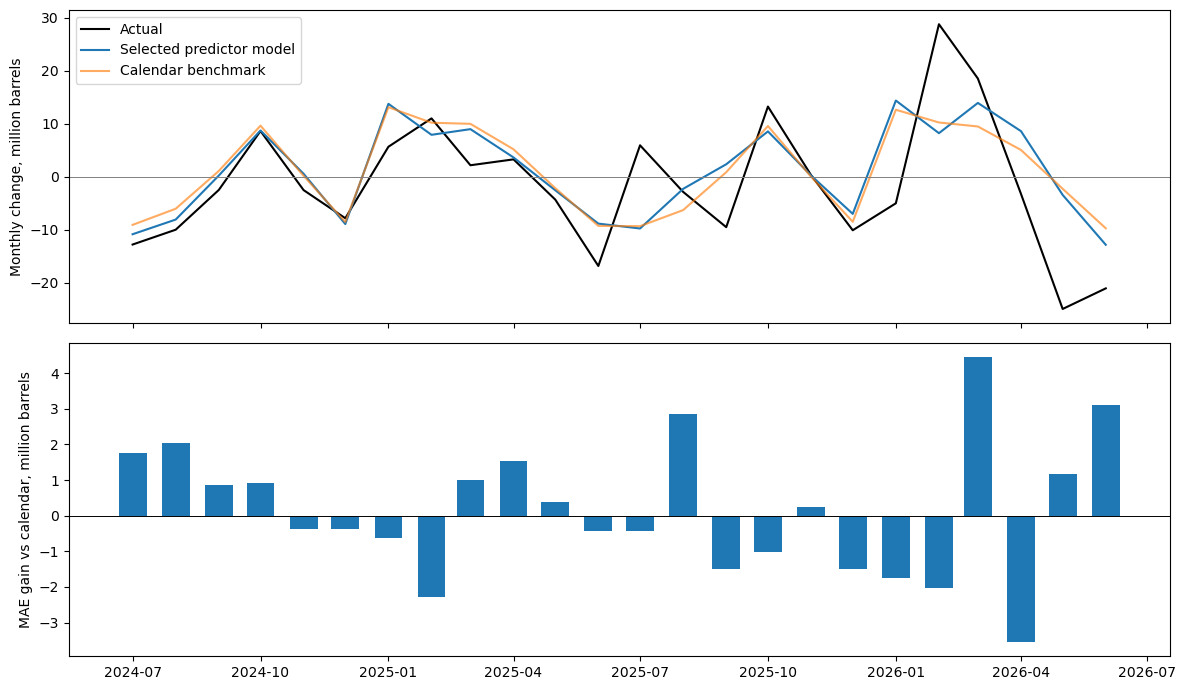

,month,fold,actual,predicted,calendar_prediction,absolute_error
0,2024-07-01,1,-12.810,-10.866181,-9.099051,1.943819
1,2024-08-01,2,-10.011,-8.097365,-6.055957,1.913635
2,2024-09-01,3,-2.510,0.205647,1.071603,2.715647
3,2024-10-01,4,8.614,8.715005,9.624817,0.101005
4,2024-11-01,5,-2.540,0.544335,0.157732,3.084335
5,2024-12-01,6,-7.845,-8.943709,-8.558217,1.098709
6,2025-01-01,7,5.641,13.744139,13.105424,8.103139
7,2025-02-01,8,10.995,7.897349,10.179042,3.097651
8,2025-03-01,9,2.152,8.965221,9.967965,6.813221
9,2025-04-01,10,3.262,3.621942,5.160089,0.359942


In [5]:
test_dates = X.index[X.index >= HOLDOUT]
assert len(test_dates) == 24
# Each month refit only on eligible observations preceding that target month.
monthly_blocks = [pd.DatetimeIndex([d]) for d in test_dates]
check_names = list(dict.fromkeys([winner, calendar_name, 'historical_month_mean', 'zero_change', full_name]))
test_predictions = {name:evaluate(*specs[name], blocks=monthly_blocks) for name in check_names}
test_metrics = pd.DataFrame([{'candidate':name, **metrics(p)} for name,p in test_predictions.items()])
display(test_metrics)
wp, bp = test_predictions[winner], test_predictions[calendar_name]
paired_gain = np.abs(bp.actual-bp.predicted).to_numpy()-np.abs(wp.actual-wp.predicted).to_numpy()
rng = np.random.default_rng(42)
# Circular three-month block bootstrap retains some serial dependence.
boots = []
for _ in range(3000):
    starts = rng.integers(0,len(paired_gain),size=8)
    ids = np.concatenate([(s+np.arange(3))%len(paired_gain) for s in starts])
    boots.append(paired_gain[ids].mean())
ci = np.quantile(boots,[0.025,0.975])
print(f'Holdout MAE gain over calendar: {paired_gain.mean():.3f} million barrels; descriptive 95% block-bootstrap interval [{ci[0]:.3f}, {ci[1]:.3f}]')
by_year = wp.assign(year=wp.month.dt.year, error=(wp.actual-wp.predicted).abs()).groupby('year').agg(months=('error','size'),mae_mb=('error','mean'))
display(by_year)
# Availability stress test: same feature definitions shifted two additional months.
# Map columns back to the original names; all noncalendar predictors become older.
X3, y3, groups3, eligible3 = make_design(lag=3)
X3.columns = X.columns
lag3 = evaluate(*specs[winner], blocks=monthly_blocks, design=(X3,y3,eligible3))
display(pd.DataFrame([{'availability':'previous month (research assumption)', **metrics(wp)},
                     {'availability':'three-month lag (stress test)', **metrics(lag3)}]))
fig, ax = plt.subplots(2,1,figsize=(12,7),sharex=True)
ax[0].plot(wp.month,wp.actual,label='Actual',color='black')
ax[0].plot(wp.month,wp.predicted,label='Selected predictor model')
ax[0].plot(bp.month,bp.predicted,label='Calendar benchmark',alpha=.65)
ax[0].axhline(0,color='grey',lw=.7); ax[0].set_ylabel('Monthly change, million barrels'); ax[0].legend()
ax[1].bar(wp.month,paired_gain,width=20); ax[1].axhline(0,color='black',lw=.7)
ax[1].set_ylabel('MAE gain vs calendar, million barrels')
plt.tight_layout(); plt.show()
display(wp.assign(calendar_prediction=bp.predicted, absolute_error=(wp.actual-wp.predicted).abs()))


In [6]:
top = addition.iloc[0]
best_features = ', '.join(individual.head(3).feature)
wm = metrics(wp)['mae_mb']; bm = metrics(bp)['mae_mb']
message = f"""## Findings
- **Focus:** forecast the national monthly inventory build/draw, conditional on prior reported monthly information.
- **Strongest added predictor group in development:** **{top['group']}**, reducing MAE by **{top.gain_vs_calendar_mb:.3f} million barrels** versus calendar alone, improving **{top.folds_improved_of_6}/6** validation blocks. A negative gain means even the top group failed to improve the benchmark.
- **Leading individual candidates:** `{best_features}`. These are incremental forecasting rankings, not causal effects.
- **Selected specification:** `{winner}`; groups: **{', '.join(specs[winner][0]) or 'none'}**.
- **July 2024–June 2026 rolling evaluation:** selected MAE **{wm:.3f} million barrels**, calendar MAE **{bm:.3f} million barrels**; gain **{100*(bm-wm)/bm:.1f}%**. The descriptive interval for the gain is **[{ci[0]:.3f}, {ci[1]:.3f}] million barrels**.
- **Interpretation:** {'The selected model improves on calendar in this period.' if wm < bm else 'The selected model does not beat calendar in this period; the added predictors are not established as a dependable improvement.'} {'The gain interval includes zero, so evidence of incremental skill is weak.' if ci[0] <= 0 <= ci[1] else 'The interval excludes zero, but only 24 months and a previously reviewed holdout limit the conclusion.'}

Group additions measure value beyond seasonality; retrained ablations measure value conditional on the other inputs. Disagreement is expected because production, demand, net balance, and trade are correlated. The month indicators should be interpreted together. Feature importance alone does not establish causality or a stable economic coefficient.

This experiment fits the national sum directly; the existing production model forecasts five PADDs and sums them. Its published errors are therefore context, not a matched benchmark. This work does not change either existing model or make claims about their year-ahead paths.
"""
display(Markdown(message))


## Findings
- **Focus:** forecast the national monthly inventory build/draw, conditional on prior reported monthly information.
- **Strongest added predictor group in development:** **inventory_history**, reducing MAE by **0.419 million barrels** versus calendar alone, improving **4/6** validation blocks. A negative gain means even the top group failed to improve the benchmark.
- **Leading individual candidates:** `change_mb_lag1, change_mean3, core_balance_kbd_lag1`. These are incremental forecasting rankings, not causal effects.
- **Selected specification:** `forward2_refinery_capacity_10`; groups: **seasonality, inventory_history, refinery_capacity**.
- **July 2024–June 2026 rolling evaluation:** selected MAE **6.714 million barrels**, calendar MAE **6.900 million barrels**; gain **2.7%**. The descriptive interval for the gain is **[-0.461, 0.886] million barrels**.
- **Interpretation:** The selected model improves on calendar in this period. The gain interval includes zero, so evidence of incremental skill is weak.

Group additions measure value beyond seasonality; retrained ablations measure value conditional on the other inputs. Disagreement is expected because production, demand, net balance, and trade are correlated. The month indicators should be interpreted together. Feature importance alone does not establish causality or a stable economic coefficient.

This experiment fits the national sum directly; the existing production model forecasts five PADDs and sums them. Its published errors are therefore context, not a matched benchmark. This work does not change either existing model or make claims about their year-ahead paths.


## Limits and next step
The sample is small and excludes a major demand shock; performance is conditional on that regime choice. Cached loaders retain flagged structural-zero assumptions in sparse flow series. Three-month averages and annual stock differences extend the training exclusion beyond the original model. The external data universe is not exhaustively searched: these conclusions concern predictors in the two existing monthly SnD datasets. Weekly releases, prices, weather, driving activity, and release-vintage data are candidates for a separate time-aligned extension, not claimed winners here. Validate the selected structure on genuinely new months before changing the production model. The three-month lag test is a sensitivity check, not proof of historical data availability.

Source lineage: `data/eia_observations.csv`, `data/source_manifest.json`, and `crude_data.py` / `gasoline_data.py` in the two sibling model directories. SHA-256 hashes above identify the exact observation snapshots used.